In [1]:
import os
import sys
import gc
import json
import time
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from pathlib import Path
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, fbeta_score
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

Using device: mps


In [4]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [5]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [6]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [7]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [8]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [9]:
CLASSES = sorted(train["class"].unique().tolist())

In [10]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x31a1ce270>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x31f18d450>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x31f18d810>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x31a15eb10>}

In [11]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [12]:
toxic_idx = train_class_to_idx['toxic']

In [13]:
class_weights = torch.tensor([1.0, 1.0, 8.0], dtype=torch.float32, device=device)

In [14]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

## Training and Validation

### Load RESNET50 Model

In [15]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

In [16]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [17]:
def run_one_epoch(model, loader, criterion, optimizer, device, is_train=False, return_preds=False):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    start_time = time.time()
    model.train() if is_train else model.eval()
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            outputs = model(img)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(img)
                loss = criterion(outputs, labels)

        preds = outputs.argmax(1)
        batch_size = img.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        total += batch_size

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            elapsed = time.time() - start_time
            print(f"  Batch {i+1}/{num_batches} | Loss: {loss.item():.4f} | "
                  f"Acc: {running_correct/total:.4f} | Time: {elapsed:.1f}s", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            
        # to clean up the memory
        del img, labels, outputs, loss, preds
        if i % 10 == 0 and device.type == 'mps':
            torch.mps.empty_cache()

    print()

    if return_preds:
        all_labels = torch.cat(all_labels).numpy()
        all_preds  = torch.cat(all_preds).numpy()
        f2 = fbeta_score(all_labels, all_preds, beta=2, average='macro')
        return (running_loss / total), (running_correct / total), total, all_labels, all_preds, f2
    else:
        return (running_loss / total), (running_correct / total), total, None, None, None

In [18]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"

In [19]:
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [20]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=5):
    best_val_f2 = -float("inf")
    bad_epochs = 0
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"\n>>> Epoch {epoch + 1}/{num_epochs} start")

        # Training (no preds needed)
        train_loss, train_acc, _, _, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True
        )
        
        # Validation WITH F2
        val_loss, val_acc, _, val_labels, val_preds, val_f2 = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=True
        )

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch + 1} Done | Time: {epoch_time:.1f}s")
        print(f"Stats: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_F2={val_f2:.4f}")

        if val_f2 > best_val_f2:
            best_val_f2 = val_f2
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f">>> New Best Val F2: {val_f2:.4f}! Model Saved.")
        else:
            bad_epochs += 1
            print(f"--- No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print("!!! Early stopping triggered.")
                break
        
        gc.collect()
        if device.type == 'mps':
            torch.mps.empty_cache()

    print(f"\n>>> Training Complete! Total Time: {(time.time() - total_start_time)/60:.1f} minutes")
    
    # Load best model
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [21]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

train(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device, patience=5)


>>> Epoch 1/30 start
  Batch 151/151 | Loss: 0.2436 | Acc: 0.5867 | Time: 530.0s
  Batch 19/19 | Loss: 0.2340 | Acc: 0.7850 | Time: 23.9s
Epoch 1 Done | Time: 554.1s
Stats: train_loss=0.3640, train_acc=0.5867, val_loss=0.2439, val_acc=0.7850, val_F2=0.7807
>>> New Best Val F2: 0.7807! Model Saved.

>>> Epoch 2/30 start
  Batch 151/151 | Loss: 0.1858 | Acc: 0.7576 | Time: 568.4s
  Batch 19/19 | Loss: 0.2166 | Acc: 0.8066 | Time: 28.1s
Epoch 2 Done | Time: 596.7s
Stats: train_loss=0.2481, train_acc=0.7576, val_loss=0.2125, val_acc=0.8066, val_F2=0.8029
>>> New Best Val F2: 0.8029! Model Saved.

>>> Epoch 3/30 start
  Batch 151/151 | Loss: 0.2419 | Acc: 0.7893 | Time: 557.8s
  Batch 19/19 | Loss: 0.2217 | Acc: 0.8149 | Time: 27.7s
Epoch 3 Done | Time: 585.6s
Stats: train_loss=0.2131, train_acc=0.7893, val_loss=0.1958, val_acc=0.8149, val_F2=0.8108
>>> New Best Val F2: 0.8108! Model Saved.

>>> Epoch 4/30 start
  Batch 151/151 | Loss: 0.1908 | Acc: 0.8146 | Time: 514.4s
  Batch 19/19 | Lo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [22]:
state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Testing

In [23]:
state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
test_loss, test_acc, test_total, test_labels, test_preds, test_f2 = run_one_epoch(model, test_loader, criterion, None, device, is_train=False, return_preds=True)

  Batch 19/19 | Loss: 0.3626 | Acc: 0.8902 | Time: 25.6s


In [25]:
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test F2 score (macro): {test_f2:.4f}")

Test accuracy: 0.8902
Test F2 score (macro): 0.8901


In [26]:
cm = confusion_matrix(test_labels, test_preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n",
      classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

Confusion matrix:
 [[1430  110   65]
 [ 115 1385  106]
 [  57   76 1473]]

Classification report:
                       precision    recall  f1-score   support

conditionally_edible     0.8926    0.8910    0.8918      1605
              edible     0.8816    0.8624    0.8719      1606
               toxic     0.8960    0.9172    0.9065      1606

            accuracy                         0.8902      4817
           macro avg     0.8901    0.8902    0.8901      4817
        weighted avg     0.8901    0.8902    0.8901      4817



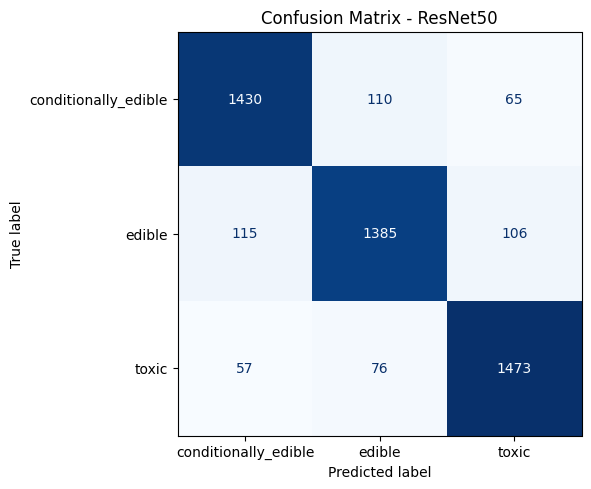

In [27]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()

# 3. SAVE FIRST, THEN SHOW
plt.savefig(save_dir / "resnet50_confusion_matrix.png", dpi=300)
plt.show()